In [1]:
import sys
import torch
import math
from xray_gaussian_rasterization_voxelization import (
    GaussianRasterizationSettings,
    GaussianRasterizer,
    GaussianVoxelizationSettings,
    GaussianVoxelizer,
)

sys.path.append("./")
from r2_gaussian.gaussian.gaussian_model import GaussianModel
from r2_gaussian.dataset.cameras import Camera
from r2_gaussian.arguments import PipelineParams

In [2]:
from r2_gaussian.dataset import Scene
from r2_gaussian.gaussian import GaussianModel, render, query, initialize_gaussian

In [3]:
from argparse import ArgumentParser
from r2_gaussian.arguments import (
    ModelParams,
    PipelineParams,
    get_combined_args,
)

In [4]:
from argparse import Namespace
from matplotlib import pyplot as plt

In [21]:
parser = ArgumentParser(description="Testing script parameters")
model = ModelParams(parser, sentinel=True)

pipeline = PipelineParams(parser)


# Namespace で引数を手動指定
args = Namespace(
    source_path="data/synthetic_dataset/cone_ntrain_75_angle_360/0_foot_cone",
    model_path="output/aEupholus_A_CT",
    data_device="cuda",
    scale_min=0.0005,
    scale_max=0.5,
    eval=True
)

dataset = model.extract(args)
scene = Scene(
    dataset
)

Reading camera 75/75 for train
Reading camera 100/100 for test
Loading Training Cameras
Camera center: tensor([-3.4983e+00,  3.5724e+00, -2.4754e-23], device='cuda:0')
Camera center: tensor([-4.8907e+00,  1.0396e+00,  1.5299e-23], device='cuda:0')
Camera center: tensor([ 4.3815e+00,  2.4088e+00, -2.7706e-23], device='cuda:0')
Camera center: tensor([4.9825e+00, 4.1839e-01, 1.0451e-23], device='cuda:0')
Camera center: tensor([4.8429e+00, 1.2434e+00, 1.3730e-23], device='cuda:0')
Camera center: tensor([1.5451e+00, 4.7553e+00, 2.9016e-23], device='cuda:0')
Camera center: tensor([3.3457e+00, 3.7157e+00, 1.7581e-23], device='cuda:0')
Camera center: tensor([-4.6489e+00,  1.8406e+00, -1.6169e-23], device='cuda:0')
Camera center: tensor([-5.2264e-01, -4.9726e+00, -4.3498e-24], device='cuda:0')
Camera center: tensor([-4.9606e+00, -6.2667e-01,  1.4666e-23], device='cuda:0')
Camera center: tensor([-3.7850e+00, -3.2671e+00,  3.3377e-23], device='cuda:0')
Camera center: tensor([-4.4786e+00, -2.2232e

In [23]:
# Set up Gaussians
gaussians = GaussianModel(None)  # scale_bound will be loaded later
loaded_iter = initialize_gaussian(gaussians, dataset, -1)
scene.gaussians = gaussians

Loading trained model at iteration 30000


In [24]:
views = scene.getTrainCameras()
print("Number of views: ", len(views))

Number of views:  75


In [25]:
import numpy as np

def spherical_to_cartesian(theta, phi, radius):
    x  = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return np.array([x, y, z])

def look_at_transform(
        center,
        lookat,
        up,
    ):
    z = lookat - center

    z = z / np.linalg.norm(z)

    x = np.cross(up, z)
    if np.all(x == 0):
        x = np.cross(up, z + np.array([1e-6, 1e-6, 1e-6]))  # Avoid zero vector
    x = x / np.linalg.norm(x)

    y = np.cross(z, x)
    R = np.stack([x, y, z], axis=1)
    t = -R.T @ center
    view_matrix = np.eye(4)
    view_matrix[:3, :3] = R
    view_matrix[:3, 3] = t
    return view_matrix

def view_matrix_from_spherical(
        theta,
        phi,
        radius,
        lookat = np.array([0, 0, 0]),
        up = np.array([0, 0, 1])
    ):
    center = spherical_to_cartesian(theta, phi, radius)
    return look_at_transform(center, lookat, up)

def get_camera(theta, phi, radius, up=np.array([0, 0, 1])):
    theta = np.array(theta)
    phi = np.array(phi)
    w2c = view_matrix_from_spherical(theta, phi, radius, up=up)
    _r = w2c[:3, :3]
    _t = w2c[:3, 3]

    return Camera(
        colmap_id=65,
        scanner_cfg=None,
        R = _r,
        T = _t, 
        angle=0.8366643629487514,
        mode=1,
        FoVx=0.5565993180102227,
        FoVy=0.5565993180102227,
        image=torch.zeros((1, 512, 512)),
        image_name="none",
        uid=15,
    )

Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([4.0000e+00, 0.0000e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([2.4493e-16, 4.0000e+00, 2.4493e-16], device='cuda:0')
tensor([[ 0.,  1., -0.,  0.],
        [ 1.,  0., -0.,  0.],
        [ 0.,  0., -1.,  0.],
        [ 0.,  0.,  4.,  1.]], device='cuda:0')
tensor([[ 0.0000e+00,  6.1232e-17, -1.0000e+00,  0.0000e+00],
        [ 1.0000e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00],
        [ 0.0000e+00, -1.0000e+00, -6.1232e-17,  0.0000e+00],
        [ 0.0000e+00, -0.0000e+00,  4.0000e+00,  1.0000e+00]], device='cuda:0')
tensor([[-0.0000e+00,  1.0000e+00, -6.1232e-17,  0.0000e+00],
        [ 6.1232e-17, -6.1232e-17, -1.0000e+00,  0.0000e+00],
        [-1.0000e+00, -3.7494e-33, -6.1232e-17,  0.0000e+00],
        [-0.0000e+00,  0.0000e+00,  4.0000e+00,  1.0000e+00]], device='cuda:0')


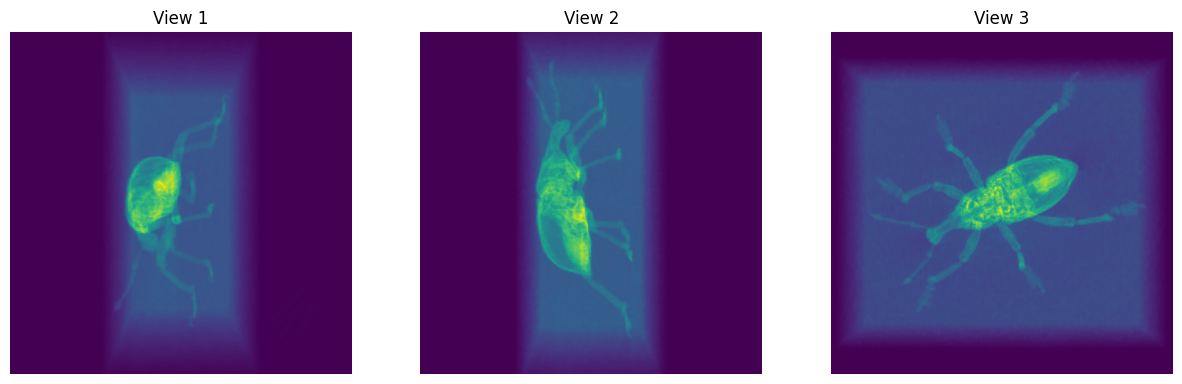

In [33]:
views = [get_camera(0, 0, 4, up=np.array([1, 0, 0])), get_camera(np.pi/2, 0, 4, up=np.array([1, 0, 0])), get_camera(np.pi/2, np.pi/2, 4, up=np.array([1, 0, 0]))]

renderings = []
for i, view in enumerate(views):
    #print(view.R, view.T)
    print(view.world_view_transform)
    rendering = render(view, gaussians, pipeline)["render"][0].detach().cpu().numpy()
    renderings.append(rendering)
    
plt.figure(figsize=(15, 5))
for i, r in enumerate(renderings):
    plt.subplot(1, len(renderings), i + 1)
    plt.imshow(r)
    plt.axis('off')
    plt.title(f"View {i + 1}")

In [10]:
from copy import deepcopy
def assign_gaussian_layers_along_plane(gaussians, origin, normal, layer_edges):
    """
    平面からの距離に応じて Gaussians を層分けする。

    Args:
        gaussians: gaussians._xyz を持つオブジェクト (N, 3)
        origin   : np.ndarray shape (3,) 平面上の1点
        normal   : np.ndarray shape (3,) 平面の法線ベクトル
        layer_edges: 距離のしきい値リスト/np配列 (単調増加)
                     例: [-0.2, 0.0, 0.2] の場合
                         distance < -0.2          → layer 0
                         -0.2 <= d < 0.0          → layer 1
                         0.0  <= d < 0.2          → layer 2
                         d >= 0.2                 → layer 3

    Returns:
        layer_ids: (N,) LongTensor 各 Gaussian の layer index
        masks    : list[BoolTensor] 各層ごとの mask (len = num_layers)
    """

    with torch.no_grad():
        device = gaussians._xyz.device
        dtype  = gaussians._xyz.dtype

        # ---- 法線・origin を tensor 化 & 正規化 ----
        normal = np.asarray(normal, dtype=np.float32)
        origin = np.asarray(origin, dtype=np.float32)

        normal = normal / (np.linalg.norm(normal) + 1e-8)
        normal = torch.from_numpy(normal).to(device=device, dtype=dtype)
        origin = torch.from_numpy(origin).to(device=device, dtype=dtype)

        # ---- 平面からの符号付き距離 d = (x - origin)·n ----
        # gaussians._xyz: (N, 3)
        distance = torch.matmul(gaussians._xyz - origin, normal)  # (N,)
        print(distance.min(), distance.max())

        # ---- しきい値を tensor 化して bucketize ----
        # layer_edges: 1D np.array / list (M,)
        edges = torch.as_tensor(layer_edges, device=device, dtype=dtype)
        # torch.bucketize: each distance -> index in [0, len(edges)]
        #   distance < edges[0]           -> 0
        #   edges[i-1] <= d < edges[i]    -> i
        #   d >= edges[-1]                -> len(edges)
        layer_ids = torch.bucketize(distance, edges).long()  # (N,)
        print(layer_ids)

        num_layers = int(edges.numel() + 1)
        masks = [(layer_ids == i) for i in range(num_layers)]

    return layer_ids, masks

def render_each_layer_safely(gaussians, layer_ids, viewpoint_cam, pipeline):
    """
    density を変更せずに各層ごとだけをレンダリングする。
    → Gaussian オブジェクトをクローンして、その層だけ残して描画。

    Args:
        gaussians    : Gaussian object
        layer_ids    : (N,) tensor, 層インデックス
        viewpoint_cam: camera

    Returns:
        layer_images : (list of Tensor) 各層ごとのレンダリング結果
    """
    num_layers = int(layer_ids.max().item()) + 1
    layer_images = []

    for ell in range(num_layers):
        mask = layer_ids == ell  # 層に属する Gaussian
        print(mask.sum())
        if mask.sum() == 0:
            layer_images.append(None)
            continue

        # 🔹 Gaussian オブジェクトを shallow copy
        g_sub = deepcopy(gaussians)

        # 🔹 各パラメータを層に属するものだけ残す
        g_sub._xyz = g_sub._xyz[mask]
        g_sub._density = g_sub._density[mask]

        if hasattr(g_sub, "_opacity"):
            g_sub._opacity = g_sub._opacity[mask]

        if hasattr(g_sub, "_scaling"):
            g_sub._scaling = g_sub._scaling[mask]

        if hasattr(g_sub, "_rotation"):
            g_sub._rotation = g_sub._rotation[mask]

        # 🔹 レンダリング
        render_pkg = render(viewpoint_cam, g_sub, pipeline)
        img = render_pkg["render"]

        if img.dim() == 4:  # [1,C,H,W]
            img = img[0].detach().cpu()
        else:               # [C,H,W]
            img = img.detach().cpu()

        layer_images.append(img)

    return layer_images

In [ ]:
origin = np.array([0.0, 0.0, 0.0], dtype=np.float32)
normal = np.array([1, 0, 0], dtype=np.float32)  # z方向に立っている平面


num_layers = 3
min_val, max_val = -1, 1
# 例: z方向の距離で 4層に分ける
layer_edges = np.linspace(min_val, max_val, num_layers)
layer_ids, masks = assign_gaussian_layers_along_plane(
    gaussians,
    origin=origin,
    normal=normal,
    layer_edges=layer_edges,
)
#viewpoint_cam = get_camera(0, 0, 4, up=np.array([1, 0, 0]))
viewpoint_cam = get_camera(np.pi/2, 0, 4, up=np.array([1, 0, 0]))
layer_images = render_each_layer_safely(gaussians, layer_ids, viewpoint_cam, pipeline)

from pathlib import Path
import matplotlib.pyplot as plt

save_dir = Path("./layer_debug")
save_dir.mkdir(parents=True, exist_ok=True)

for i, img in enumerate(layer_images):
    if img is None:
        continue  # 該当Gaussianがなかった層
    if img.shape[0] == 1:
        plt.imsave(save_dir / f"layer_{i:02d}.png", img[0].numpy(), cmap='gray')
    else:
        plt.imsave(save_dir / f"layer_{i:02d}.png", img.permute(1,2,0).numpy())


tensor(-1.1289, device='cuda:0') tensor(1.1669, device='cuda:0')
tensor([1, 2, 2,  ..., 1, 2, 2], device='cuda:0')
Camera center: tensor([4.0000e+00, 0.0000e+00, 2.4493e-16], device='cuda:0')
tensor(28, device='cuda:0')
tensor(49371, device='cuda:0')
tensor(43877, device='cuda:0')
tensor(23, device='cuda:0')


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from pathlib import Path
import imageio.v3 as iio  # GIF 書き出し用
import torch

def render_parallax_colored_output(
    gaussians,
    layer_ids,
    viewpoint_cam,
    pipeline,
    max_shift,
    num_frames=21,
    out_dir="./parallax_debug",
    fps=10,
):
    """
    Gaussian は gray scale のままレンダリングし、出力画像に層ごとの色を付けて保存 & GIF 生成。
    """
    device = gaussians._xyz.device
    dtype  = gaussians._xyz.dtype

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    num_layers = int(layer_ids.max().item()) + 1

    # # 🔸 奥が最も動かず、手前が最も動く
    # alpha = torch.linspace(0.001, 1.0, steps=num_layers, device=device, dtype=dtype)
    # alpha_per_gauss = alpha[layer_ids]  # (N,)
    # 層番号 (0=奥 → num_layers-1=手前)
    layer_idx = torch.arange(num_layers, device=device, dtype=dtype)

    # 指数的に強調（β=2〜4ぐらいが自然）
    beta = 3.0  
    alpha = (layer_idx / (num_layers - 1)).pow(beta)

    # 任意でスケール調整
    alpha = 0.001 + 0.999 * alpha  # 必要なら
    # 🔹 層ごとのカラー（RGB）
    layer_color_factors = torch.ones((num_layers, 3), device=device, dtype=dtype)
    layer_color_factors *= torch.tensor([1,1, 1], device=device, dtype=dtype)
    frames = []
    alpha_per_gauss = alpha[layer_ids]

    for f in range(num_frames):
        
        # 時間パラメータ
        t = (f / (num_frames - 1)) * 2.0 - 1.0  # -1 → 1
        base_dx = t * max_shift
        base_delta = torch.tensor([0, base_dx, 0.0], device=device, dtype=dtype)

        # Gaussian コピー＆移動
        g_anim = deepcopy(gaussians)
        with torch.no_grad():
            g_anim._xyz = g_anim._xyz + alpha_per_gauss.unsqueeze(1) * base_delta.unsqueeze(0)

        # レンダリング（gray image）
        render_pkg = render(viewpoint_cam, g_anim, pipeline)
        img = render_pkg["render"]

        if img.dim() == 4:
            img = img[0]  # [C,H,W]

        img_np = img.detach().cpu().numpy()  # [1,H,W] or [C,H,W]

        # 🔥 強制的に grayscale として扱う（X線なら 1ch 想定）
        if img_np.ndim == 3:
            gray = img_np[0]  # [H,W]
        else:
            gray = img_np

        # 🎨 色付け：RGB 3ch に拡張 + 層ごとの色を乗算
        for layer_idx in range(num_layers):
            if (layer_ids == layer_idx).any():
                color = layer_color_factors[layer_idx].cpu().numpy()
                colored = np.stack([gray * color[0],
                                    gray * color[1],
                                    gray * color[2]], axis=-1)
            else:
                continue

        # 拡散後フレーム保存
        frame_img = (colored * 255).clip(0, 255).astype(np.uint8)
        frames.append(frame_img)
        

        plt.imsave(out_dir / f"parallax_{f:03d}.png", frame_img)
        print(f"Saved: parallax_{f:03d}.png")

    # 🎬 GIF 生成
    gif_path = out_dir / "parallax.gif"
    iio.imwrite(gif_path, frames, fps=fps)
    print(f"\n🎉 GIF saved → {gif_path}")


In [32]:
import imageio.v3 as iio
render_parallax_colored_output(
    gaussians,
    layer_ids,
    viewpoint_cam,
    pipeline,
    num_frames=21,
    max_shift=0.2,
    out_dir="./parallax_debug",
    fps=10,
)


Saved: parallax_000.png
Saved: parallax_001.png
Saved: parallax_002.png
Saved: parallax_003.png
Saved: parallax_004.png
Saved: parallax_005.png
Saved: parallax_006.png
Saved: parallax_007.png
Saved: parallax_008.png
Saved: parallax_009.png
Saved: parallax_010.png
Saved: parallax_011.png
Saved: parallax_012.png
Saved: parallax_013.png
Saved: parallax_014.png
Saved: parallax_015.png
Saved: parallax_016.png
Saved: parallax_017.png
Saved: parallax_018.png
Saved: parallax_019.png
Saved: parallax_020.png

🎉 GIF saved → parallax_debug\parallax.gif


In [35]:
def cut_gaussians_by_plane(gaussians, origin, normal, d=1e-1):
    with torch.no_grad():
        # 正規化された法線ベクトル
        normal = normal / np.linalg.norm(normal)
        normal = torch.from_numpy(normal).to(gaussians._xyz.device, dtype=gaussians._xyz.dtype)

        # originもtensorに変換
        origin = torch.from_numpy(origin).to(gaussians._xyz.device, dtype=gaussians._xyz.dtype)

        # 各centerから平面までの符号付き距離を計算
        distance = torch.abs(torch.matmul(gaussians._xyz - origin, normal))

        mask  = distance > d
        gaussians._density[mask] = -100

def cut_gaussians_beyond_plane(gaussians, origin, normal, d=1e-1):
    with torch.no_grad():
        # 正規化された法線ベクトル
        normal = normal / np.linalg.norm(normal)
        normal = torch.from_numpy(normal).to(gaussians._xyz.device, dtype=gaussians._xyz.dtype)

        # originもtensorに変換
        origin = torch.from_numpy(origin).to(gaussians._xyz.device, dtype=gaussians._xyz.dtype)

        # 各centerから平面までの符号付き距離を計算
        distance = torch.matmul(gaussians._xyz - origin, normal)

        mask  = distance < 0
        gaussians._density[mask] = -100

In [36]:
def get_image(theta, phi, radius, z, slice=True, up=np.array([1, 0, 0])):
    copy_gaussians = copy.deepcopy(gaussians)

    camera_center = spherical_to_cartesian(theta, phi, radius + z)
    normal_vector = camera_center / np.linalg.norm(camera_center)

    origin = np.array([0, 0, 0]) - normal_vector * z
    if slice:
        cut_gaussians_by_plane(copy_gaussians, origin, normal=normal_vector)
    else:
        cut_gaussians_beyond_plane(copy_gaussians, origin, normal=normal_vector)

    view = get_camera(theta, phi, radius, up=up)

    rendering = render(view, copy_gaussians, pipeline)["render"][0].detach().cpu().numpy()
    return rendering

rendering = get_image(0, 0, 4, 0.01)
plt.imshow(rendering)
plt.axis('off')
plt.title("Image at z=0.01")


NameError: name 'copy' is not defined

In [39]:
import tqdm
import copy

In [40]:
# アニメーションを作成(gifファイルとして出力)
import imageio
import matplotlib.cm as cm

def create_gif(renderings, filename="output.gif", duration=0.1, colormap='jet'):
    """
    レンダリング結果からGIFアニメーションを作成
    
    Parameters:
    -----------
    renderings : list
        レンダリング結果の配列
    filename : str
        保存するファイル名
    duration : float
        フレーム間の時間（秒）
    colormap : str
        使用するカラーマップ名 ('jet', 'viridis', 'plasma'等)
    """
    # カラーマップを取得
    cmap = cm.get_cmap(colormap)
    
    # 画像配列を作成
    images = []
    for rendering in renderings:
        # 画像を0-1の範囲に正規化
        if rendering.min() != rendering.max():  # 分母が0にならないように確認
            normalized = (rendering - rendering.min()) / (rendering.max() - rendering.min())
        else:
            normalized = rendering
            
        # カラーマップを適用
        colored = cmap(normalized)
        
        # RGBA画像をRGB uint8に変換
        rgb_uint8 = (colored[:, :, :3] * 255).astype(np.uint8)
        images.append(rgb_uint8)
    
    # GIFとして保存
    imageio.mimsave(filename, images, duration=duration)
    print(f"GIFをファイル '{filename}' に保存しました")

# 使用例 - zを変化させたレンダリング結果からGIF作成
z_values = np.linspace(-1, 1, 50)  # フレーム数を50に減らして処理速度向上
renderings_slice = []
renderings = []

for z in tqdm.tqdm(z_values, desc="Z平面でのレンダリング"):
    rendering = get_image(0, 0, 4, z, slice=False)
    renderings.append(rendering)

    rendering = get_image(0, 0, 4, z, slice=True)
    renderings_slice.append(rendering)

# GIF作成（複数のカラーマップでテスト）
create_gif(renderings_slice, filename="slices_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_slice, filename="slices_viridis.gif", duration=0.1, colormap='viridis')

create_gif(renderings, filename="beyond_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings, filename="beyond_viridis.gif", duration=0.1, colormap='viridis')



Z平面でのレンダリング:   2%|▏         | 1/50 [00:00<00:06,  7.79it/s]

Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')


Z平面でのレンダリング:  20%|██        | 10/50 [00:00<00:01, 36.14it/s]

Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cu

Z平面でのレンダリング:  48%|████▊     | 24/50 [00:00<00:00, 53.22it/s]

Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cu

Z平面でのレンダリング:  76%|███████▌  | 38/50 [00:00<00:00, 59.25it/s]

Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cu

Z平面でのレンダリング: 100%|██████████| 50/50 [00:00<00:00, 52.77it/s]
C:\Users\Maemaeko\AppData\Local\Temp\ipykernel_2600\2858116868.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
GIFをファイル 'slices_jet.gif' に保存しました
GIFをファイル 'slices_viridis.gi

In [41]:
# 使用例 - thetaを変化させたレンダリング結果からGIF作成
theta_values = np.linspace(0, np.pi/2, 50)  # フレーム数を50に減らして処理速度向上

#phi_values = np.linspace(0, 2 * np.pi, 50)
renderings_theta_phi = []
renderings_theta_phi_slice = []
for theta in tqdm.tqdm(theta_values, desc="ThetaとPhiでのレンダリング"):
    #for phi in phi_values:
    rendering = get_image(theta, 0, 4, 0.01)
    renderings_theta_phi_slice.append(rendering)

    rendering = get_image(theta, 0, 4, 0.01, slice=False)
    renderings_theta_phi.append(rendering)

# GIF作成（複数のカラーマップでテスト）
create_gif(renderings_theta_phi_slice, filename="theta_slice_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_theta_phi_slice, filename="theta_slice_viridis.gif", duration=0.1, colormap='viridis')
create_gif(renderings_theta_phi, filename="theta_beyond_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_theta_phi, filename="theta_beyond_viridis.gif", duration=0.1, colormap='viridis')

ThetaとPhiでのレンダリング:   2%|▏         | 1/50 [00:00<00:05,  8.42it/s]

Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0., 0., 4.], device='cuda:0')
Camera center: tensor([0.1282, 0.0000, 3.9979], device='cuda:0')
Camera center: tensor([0.1282, 0.0000, 3.9979], device='cuda:0')


ThetaとPhiでのレンダリング:  12%|█▏        | 6/50 [00:00<00:02, 21.49it/s]

Camera center: tensor([0.2563, 0.0000, 3.9918], device='cuda:0')
Camera center: tensor([0.2563, 0.0000, 3.9918], device='cuda:0')
Camera center: tensor([0.3841, 0.0000, 3.9815], device='cuda:0')
Camera center: tensor([0.3841, 0.0000, 3.9815], device='cuda:0')
Camera center: tensor([0.5115, 0.0000, 3.9672], device='cuda:0')
Camera center: tensor([0.5115, 0.0000, 3.9672], device='cuda:0')
Camera center: tensor([0.6384, 0.0000, 3.9487], device='cuda:0')
Camera center: tensor([0.6384, 0.0000, 3.9487], device='cuda:0')
Camera center: tensor([0.7646, 0.0000, 3.9262], device='cuda:0')
Camera center: tensor([0.7646, 0.0000, 3.9262], device='cuda:0')
Camera center: tensor([0.8901, 0.0000, 3.8997], device='cuda:0')
Camera center: tensor([0.8901, 0.0000, 3.8997], device='cuda:0')
Camera center: tensor([1.0146, 0.0000, 3.8692], device='cuda:0')
Camera center: tensor([1.0146, 0.0000, 3.8692], device='cuda:0')
Camera center: tensor([1.1381, 0.0000, 3.8347], device='cuda:0')
Camera center: tensor([1.

ThetaとPhiでのレンダリング:  38%|███▊      | 19/50 [00:00<00:00, 44.85it/s]

...

Camera center: tensor([2.7827, 0.0000, 2.8734], device='cuda:0')
Camera center: tensor([2.8734, 0.0000, 2.7827], device='cuda:0')
Camera center: tensor([2.8734, 0.0000, 2.7827], device='cuda:0')
Camera center: tensor([2.9611, 0.0000, 2.6892], device='cuda:0')
Camera center: tensor([2.9611, 0.0000, 2.6892], device='cuda:0')
Camera center: tensor([3.0458, 0.0000, 2.5929], device='cuda:0')
Camera center: tensor([3.0458, 0.0000, 2.5929], device='cuda:0')
Camera center: tensor([3.1273, 0.0000, 2.4940], device='cuda:0')
Camera center: tensor([3.1273, 0.0000, 2.4940], device='cuda:0')
Camera center: tensor([3.2057, 0.0000, 2.3924], device='cuda:0')
Camera center: tensor([3.2057, 0.0000, 2.3924], device='cuda:0')
Camera center: tensor([3.2807, 0.0000, 2.2885], device='cuda:0')
Camera center: tensor([3.2807, 0.0000, 2.2885], device='cuda:0')
Camera center: tensor([3.3524, 0.0000, 2.1821], device='cuda:0')
Camera center: tensor([3.3524, 0.0000, 2.1821], device='cuda:0')
Camera center: tensor([3.

ThetaとPhiでのレンダリング: 100%|██████████| 50/50 [00:01<00:00, 48.89it/s]

tensor([3.7539, 0.0000, 1.3815], device='cuda:0')
Camera center: tensor([3.7539, 0.0000, 1.3815], device='cuda:0')
Camera center: tensor([3.7962, 0.0000, 1.2604], device='cuda:0')
Camera center: tensor([3.7962, 0.0000, 1.2604], device='cuda:0')
Camera center: tensor([3.8347, 0.0000, 1.1381], device='cuda:0')
Camera center: tensor([3.8347, 0.0000, 1.1381], device='cuda:0')
Camera center: tensor([3.8692, 0.0000, 1.0146], device='cuda:0')
Camera center: tensor([3.8692, 0.0000, 1.0146], device='cuda:0')
Camera center: tensor([3.8997, 0.0000, 0.8901], device='cuda:0')
Camera center: tensor([3.8997, 0.0000, 0.8901], device='cuda:0')
Camera center: tensor([3.9262, 0.0000, 0.7646], device='cuda:0')
Camera center: tensor([3.9262, 0.0000, 0.7646], device='cuda:0')
Camera center: tensor([3.9487, 0.0000, 0.6384], device='cuda:0')
Camera center: tensor([3.9487, 0.0000, 0.6384], device='cuda:0')
Camera center: tensor([3.9672, 0.0000, 0.5115], device='cuda:0')
Camera center: tensor([3.9672, 0.0000, 0


C:\Users\Maemaeko\AppData\Local\Temp\ipykernel_2600\2858116868.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


GIFをファイル 'theta_slice_jet.gif' に保存しました
GIFをファイル 'theta_slice_viridis.gif' に保存しました
GIFをファイル 'theta_beyond_jet.gif' に保存しました
GIFをファイル 'theta_beyond_viridis.gif' に保存しました


In [42]:
# 使用例 - phiを変化させたレンダリング結果からGIF作成
phi_values = np.linspace(0.01, np.pi, 50)  # フレーム数を50に減らして処理速度向上
renderings_phi = []
renderings_phi_slice = []
for phi in tqdm.tqdm(phi_values, desc="Phiでのレンダリング"):
    rendering = get_image(np.pi/2, phi, 4, 0.01, up=np.array([0, 0, -1]))
    renderings_phi_slice.append(rendering)
    rendering = get_image(np.pi/2, phi, 4, 0.01, slice=False, up=np.array([0, 0, -1]))
    renderings_phi.append(rendering)
# GIF作成（複数のカラーマップでテスト）
create_gif(renderings_phi_slice, filename="phi_slice_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_phi_slice, filename="phi_slice_viridis.gif", duration=0.1, colormap='viridis')
create_gif(renderings_phi, filename="phi_beyond_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_phi, filename="phi_beyond_viridis.gif", duration=0.1, colormap='viridis')

Phiでのレンダリング:   2%|▏         | 1/50 [00:00<00:08,  5.61it/s]

Camera center: tensor([3.9998e+00, 3.9999e-02, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.9998e+00, 3.9999e-02, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.9891e+00, 2.9537e-01, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.9891e+00, 2.9537e-01, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.9621e+00, 5.4954e-01, 2.4493e-16], device='cuda:0')


Phiでのレンダリング:  30%|███       | 15/50 [00:00<00:00, 46.44it/s]

Camera center: tensor([3.9621e+00, 5.4954e-01, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.9189e+00, 8.0146e-01, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.9189e+00, 8.0146e-01, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.8597e+00, 1.0501e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.8597e+00, 1.0501e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.7848e+00, 1.2945e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.7848e+00, 1.2945e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.6944e+00, 1.5335e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.6944e+00, 1.5335e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.5889e+00, 1.7664e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.5889e+00, 1.7664e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.4687e+00, 1.9920e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([3.4687e+00, 1.9920e+00, 2.4493e-16], device='cuda:0')

Phiでのレンダリング:  44%|████▍     | 22/50 [00:00<00:00, 53.65it/s]

Camera center: tensor([2.2656e+00, 3.2965e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([2.2656e+00, 3.2965e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([2.0505e+00, 3.4345e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([2.0505e+00, 3.4345e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([1.8270e+00, 3.5584e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([1.8270e+00, 3.5584e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([1.5960e+00, 3.6678e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([1.5960e+00, 3.6678e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([1.3585e+00, 3.7623e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([1.3585e+00, 3.7623e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([1.1154e+00, 3.8413e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([1.1154e+00, 3.8413e+00, 2.4493e-16], device='cuda:0')
Camera center: tensor([8.6779e-01, 3.9047e+00, 2.4493e-16], device='cuda:0')

Phiでのレンダリング:  72%|███████▏  | 36/50 [00:00<00:00, 61.45it/s]

Camera center: tensor([-9.0679e-01,  3.8959e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-1.1538e+00,  3.8300e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-1.1538e+00,  3.8300e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-1.3960e+00,  3.7485e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-1.3960e+00,  3.7485e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-1.6326e+00,  3.6517e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-1.6326e+00,  3.6517e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-1.8624e+00,  3.5400e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-1.8624e+00,  3.5400e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-2.0847e+00,  3.4138e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-2.0847e+00,  3.4138e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-2.2985e+00,  3.2737e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-2.2985e+00,  3.2

Phiでのレンダリング: 100%|██████████| 50/50 [00:00<00:00, 54.85it/s]
C:\Users\Maemaeko\AppData\Local\Temp\ipykernel_2600\2858116868.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


Camera center: tensor([-3.7095e+00,  1.4965e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.7095e+00,  1.4965e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.7975e+00,  1.2566e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.7975e+00,  1.2566e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.8700e+00,  1.0115e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.8700e+00,  1.0115e+00,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.9267e+00,  7.6223e-01,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.9267e+00,  7.6223e-01,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.9674e+00,  5.0989e-01,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.9674e+00,  5.0989e-01,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.9918e+00,  2.5547e-01,  2.4493e-16], device='cuda:0')
Camera center: tensor([-3.9918e+00,  2.5547e-01,  2.4493e-16], device='cuda:0')
Camera center: tensor([-4.0000e+00,  4.8

In [ ]:
# 球面座標系の可視化（ブラッシュアップ版）

import numpy as np
import matplotlib.pyplot as plt

# 球面座標系 (r, theta, phi) からデカルト座標 (x, y, z) への変換
def spherical_to_cartesian(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return x, y, z

# パラメータ範囲
r = 1
theta = np.linspace(0, np.pi, 60)      # 分解能を上げる
phi = np.linspace(0, 2 * np.pi, 120)

# メッシュグリッド作成
theta_grid, phi_grid = np.meshgrid(theta, phi)

# デカルト座標に変換
x, y, z = spherical_to_cartesian(r, theta_grid, phi_grid)

# 3Dプロット
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_wireframe(x, y, z, color='k', linewidth=0.7, alpha=0.4)

# 球面座標の軸を描画
ax.quiver(0, 0, 0, 1.2, 0, 0, color='r', arrow_length_ratio=0.08, linewidth=1)
ax.quiver(0, 0, 0, 0, 1.2, 0, color='g', arrow_length_ratio=0.08, linewidth=1)
ax.quiver(0, 0, 0, 0, 0, 1.2, color='b', arrow_length_ratio=0.08, linewidth=1)

# theta, phi の例点をプロット
# sample_theta = np.pi / 4
# sample_phi = np.pi / 3
# sample_x, sample_y, sample_z = spherical_to_cartesian(r, sample_theta, sample_phi)
# ax.scatter(sample_x, sample_y, sample_z, color='magenta', s=80, label='(θ, φ) example')

z_values = np.linspace(-1, 1, 50)  # フレーム数を50に減らして処理速度向上
for z in z_values:
    sample_x, sample_y, sample_z = spherical_to_cartesian(r, 0, 0)
    look_at_transform
    ax.scatter(sample_x, sample_y, z, color='green', s=10)


theta_values = np.linspace(np.pi / 2, 0, 50) 
phi_values = np.zeros_like(theta_values)
for theta, phi in zip(theta_values, phi_values):
    sample_x, sample_y, sample_z = spherical_to_cartesian(r, theta, phi)
    ax.scatter(sample_x, sample_y, sample_z, color='red', s=10)


phi_values = np.linspace(0, np.pi, 50)
theta_values = np.ones_like(phi_values) * np.pi / 2 
for theta, phi in zip(theta_values, phi_values):
    sample_x, sample_y, sample_z = spherical_to_cartesian(r, theta, phi)
    ax.scatter(sample_x, sample_y, sample_z, color='blue', s=10)



# ラベル・タイトル
# ax.set_xlabel('X', fontsize=12)
# ax.set_ylabel('Y', fontsize=12)
# ax.set_zlabel('Z', fontsize=12)
# ax.set_title('球面座標系の可視化', fontsize=15)
ax.set_box_aspect([1,1,1])

# 凡例
ax.legend(loc='upper left')

# スケール調整
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

plt.tight_layout()
plt.show()